# NS → QS conversion via baryonic-mass accretion

Pipeline:
1. Read hadronic (`_h`) and quark (`_q`) EOS tables: `nB[fm^-3] P[MeV/fm^3] e[MeV/fm^3] Ys`.
2. Solve TOV for both → stable M(e_c), M_b(e_c) sequences.
3. Build  MH(M_b), M_b^H(MH), MQ(M_b)  and the deconfinement threshold
   **M_conv** = mass of the hadronic star whose central strangeness density
   n_S = Y_s · n_B reaches n0 = 0.158 fm⁻³.
4. Monte-Carlo a population: initial NS mass MH_init and accreted baryonic
   mass M_b,acc. Conserve baryonic mass; if the post-accretion baryonic mass
   exceeds M_b(M_conv) the star deconfines to a quark star (mass = MQ(M_b)),
   else it stays a NS (mass = MH(M_b)); if it exceeds the QS branch → BH.

**Initial NS mass distribution.** The canonical pre-accretion NS mass is well
constrained for double-NS systems: mean ≈ 1.33 M_⊙ with a narrow spread
σ ≈ 0.05–0.09 (Kiziltan et al. 2013, ApJ 778, 66; Özel & Freire 2016,
ARA&A 54, 401; Antoniadis et al. 2016 find a bimodal birth distribution with
peaks ≈ 1.34 and 1.47 M_⊙). We default to N(1.30, 0.05) per the request; switch
`MU_INIT, SIGMA_INIT` to (1.33, 0.09) for the Özel & Freire value.

**Accreted baryonic mass.** Default: flat U(0.01, 1.0) M_⊙ (toggle to Gaussian below).


In [2]:
# --- make the live source-tree `eos` package importable from notebooks/ ---
import sys, os
_d = os.getcwd()
for _ in range(6):
    if os.path.isdir(os.path.join(_d, "eos", "tov")):
        if _d not in sys.path:
            sys.path.insert(0, _d)
        break
    _d = os.path.dirname(_d)

import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import PchipInterpolator
from scipy.optimize import brentq

from eos.tov.solver import EOSTable_for_TOV, compute_tov_sequence, find_mmax_precise
from eos.abpr.eos import (
    ABPRParams, pressure_abpr, baryon_density_abpr, energy_density_abpr, mu_from_P_abpr,
)

plt.rcParams.update({"figure.dpi": 120, "font.size": 11, "axes.grid": True,
                     "grid.alpha": 0.3, "lines.linewidth": 2})

# ---------------- hadronic EOS (from file) ----------------
RESEARCH = "/Users/mircoguerrini/Desktop/Research"
H_PATH = os.path.join(RESEARCH, "best_model_eos_h.txt")
EOS_COLS = (1, 2, 0)          # file cols  nB P E Ys  ->  (P, e, nB)

# ---------------- quark EOS: ABPR (CFL, T=0) ----------------
# Bag = B^(1/4) [MeV] -> B4 ;  ms = strange-quark mass [MeV]
abpr_q = ABPRParams(name="best_q", ms=100.0, Delta=157.0, a4=0.92, B4=158.0)
print(f"ABPR quark EOS: ms={abpr_q.ms}, Delta={abpr_q.Delta}, a4={abpr_q.a4}, "
      f"B^1/4={abpr_q.B4} MeV  (alpha_s={abpr_q.alpha:.3f}, B={abpr_q.B:.1f} MeV/fm^3)")

# ---------------- physics knobs ----------------
NS_SAT = 0.158                # n0 [fm^-3]: deconfine when central n_S = Y_s*n_B reaches this
print("H file:", "OK" if os.path.exists(H_PATH) else "MISSING", H_PATH)


ABPR quark EOS: ms=100.0, Delta=157.0, a4=0.92, B^1/4=158.0 MeV  (alpha_s=0.126, B=81.1 MeV/fm^3)
H file: OK /Users/mircoguerrini/Desktop/Research/best_model_eos_h.txt


In [3]:
# Raw arrays (nB, P, e, Ys) for the hadronic table — needed for the n_S threshold.
raw_h = np.loadtxt(H_PATH)            # comments '#' skipped by default
nB_h, P_h, e_h, Ys_h = raw_h[:,0], raw_h[:,1], raw_h[:,2], raw_h[:,3]

# strangeness density n_S = Ys * nB, as a function of nB (monotone-ish at high density)
nS_h = Ys_h * nB_h
order = np.argsort(nB_h)
nS_of_nB = PchipInterpolator(nB_h[order], nS_h[order], extrapolate=False)

print(f"H table: {len(nB_h)} rows, nB in [{nB_h.min():.2e}, {nB_h.max():.3f}] fm^-3, "
      f"max n_S = {nS_h.max():.3f} fm^-3")
print(f"Threshold n_S = {NS_SAT} reachable: {nS_h.max() >= NS_SAT}")


H table: 446 rows, nB in [4.73e-15, 1.887] fm^-3, max n_S = 0.451 fm^-3
Threshold n_S = 0.158 reachable: True


In [4]:
# Quark EOS table (P, e, nB) from ABPR, from the self-bound surface (P=0) upward.
# Strange-star surface: P=0 at finite nB (no crust).
mu_surf, _ = mu_from_P_abpr(0.0, abpr_q)            # mu where P = 0
mu_grid = np.linspace(mu_surf, 850.0, 600)          # MeV

P_q  = np.array([pressure_abpr(m, abpr_q)       for m in mu_grid])
e_q  = np.array([energy_density_abpr(m, abpr_q) for m in mu_grid])
nB_q = np.array([baryon_density_abpr(m, abpr_q) for m in mu_grid])

eos_q = EOSTable_for_TOV(P=P_q, epsilon=e_q, nB=nB_q)
print(f"quark EOS: {len(mu_grid)} pts | surface P=0 at nB={nB_q[0]:.3f} fm^-3, "
      f"e={e_q[0]:.1f} MeV/fm^3 | e up to {e_q[-1]:.0f} MeV/fm^3")


quark EOS: 600 pts | surface P=0 at nB=0.309 fm^-3, e=223.1 MeV/fm^3 | e up to 14963 MeV/fm^3


In [5]:
# Central energy-density grids (solver truncates to the stable branch).
e_c_h = np.logspace(np.log10(150.0),        np.log10(2400.0), 90)   # hadronic
e_c_q = np.logspace(np.log10(e_q[0] * 1.02), np.log10(8000.0), 90)  # quark (above surface)

def tov_stable(eos_input, e_c_vec, cols=None):
    """Return stable-branch [e_c, n_c, P_c, R, M, M_b], M_max, e_c_max.
    eos_input: path (str) or EOSTable_for_TOV object."""
    kw = dict(add_crust_table="No", compute_baryonic_mass=True,
              compute_tidal=False, verbose=False)
    if isinstance(eos_input, str):
        kw["eos_columns"] = cols
    res = compute_tov_sequence(eos_input, e_c_vec, **kw)
    idx_max, e_c_max, M_max = find_mmax_precise(res)
    return res[:idx_max + 1], float(M_max), float(e_c_max)

seq_h, Mmax_h, ecmax_h = tov_stable(H_PATH, e_c_h, cols=EOS_COLS)
seq_q, Mmax_q, ecmax_q = tov_stable(eos_q,   e_c_q)

print(f"Hadronic: M_max = {Mmax_h:.3f} M_sun @ e_c={ecmax_h:.0f}  ({len(seq_h)} pts)")
print(f"Quark   : M_max = {Mmax_q:.3f} M_sun @ e_c={ecmax_q:.0f}  ({len(seq_q)} pts)")


Hadronic: M_max = 1.513 M_sun @ e_c=1651  (78 pts)
Quark   : M_max = 2.376 M_sun @ e_c=923  (35 pts)


In [6]:
# stable-branch columns: 0=e_c, 1=n_c, 2=P_c, 3=R, 4=M, 5=M_b
ec_h, nc_h, Mgr_h, Mb_h = seq_h[:,0], seq_h[:,1], seq_h[:,4], seq_h[:,5]
ec_q, nc_q, Mgr_q, Mb_q = seq_q[:,0], seq_q[:,1], seq_q[:,4], seq_q[:,5]

def _mono(x, y):
    """PchipInterpolator on strictly increasing x (sort + dedupe)."""
    o = np.argsort(x); x, y = x[o], y[o]
    keep = np.concatenate(([True], np.diff(x) > 0))
    return PchipInterpolator(x[keep], y[keep], extrapolate=False)

# Hadronic: gravitational <-> baryonic, and M vs central density
MH      = _mono(Mb_h,  Mgr_h)   # MH(M_b)        gravitational mass of hadronic star
MbH     = _mono(Mgr_h, Mb_h)    # M_b^H(MH)      baryonic mass of hadronic star
M_of_nc = _mono(nc_h,  Mgr_h)   # M(n_c)
Mb_of_nc= _mono(nc_h,  Mb_h)    # M_b(n_c)

# Quark: gravitational vs baryonic
MQ      = _mono(Mb_q,  Mgr_q)   # MQ(M_b)        gravitational mass of quark star
Mb_max_Q = float(Mb_q.max())    # max baryonic mass on the QS branch (above -> BH)

# --- deconfinement threshold: central n_S = NS_SAT ---
prod = nS_h[order]; nB_s = nB_h[order]
i_cross = np.argmax(prod >= NS_SAT)              # first index reaching the threshold
nB_star = brentq(lambda x: float(nS_of_nB(x)) - NS_SAT, nB_s[i_cross-1], nB_s[i_cross])

if nB_star <= nc_h.max():
    M_conv  = float(M_of_nc(nB_star))            # = MHcritdeconfinement
    Mb_conv = float(Mb_of_nc(nB_star))
else:
    print("WARNING: n_S threshold is reached only beyond the hadronic M_max "
          "(unstable branch) -> using M_max as the conversion ceiling.")
    M_conv, Mb_conv = Mmax_h, float(Mb_h.max())

print(f"n_S = {NS_SAT} reached at central nB* = {nB_star:.3f} fm^-3")
print(f"M_conv (MHcritdeconfinement) = {M_conv:.3f} M_sun   "
      f"(M_b,conv = {Mb_conv:.3f} M_sun)")
print(f"hadronic M_max = {Mmax_h:.3f}  ->  conversion {'BEFORE' if M_conv < Mmax_h else 'AFTER'} M_max")


n_S = 0.158 reached at central nB* = 1.246 fm^-3
M_conv (MHcritdeconfinement) = 1.510 M_sun   (M_b,conv = 1.691 M_sun)
hadronic M_max = 1.513  ->  conversion BEFORE M_max


In [7]:
# Faithful translation of the Mathematica functions (uses gravitational-mass test).
# NOTE: extrapolate=False -> MH/MQ return nan outside their stable range; guard for that.
def MHfinal(Mb_acc, MH_init):
    M_had = MH(MbH(MH_init) + Mb_acc)
    return float(M_had) if np.isfinite(M_had) and M_had < M_conv else None

def MQfinal(Mb_acc, MH_init):
    Mb_new = MbH(MH_init) + Mb_acc
    M_had  = MH(Mb_new)                     # would-be hadronic mass
    deconfine = (not np.isfinite(M_had)) or (M_had > M_conv)   # nan = past hadronic branch
    return float(MQ(Mb_new)) if deconfine else None

# Equivalent classifier on baryonic mass (vectorized, avoids extrapolation ambiguity).
def final_state(MH_init, Mb_acc):
    """Return (M_final[M_sun], kind) with kind in {'NS','QS','BH'}."""
    MH_init = np.asarray(MH_init, float); Mb_acc = np.asarray(Mb_acc, float)
    Mb_new = MbH(MH_init) + Mb_acc
    kind = np.where(Mb_new <= Mb_conv, "NS",
           np.where(Mb_new <= Mb_max_Q, "QS", "BH"))
    M = np.full_like(Mb_new, np.nan)
    ns = (kind == "NS"); qs = (kind == "QS")
    M[ns] = MH(Mb_new[ns])
    M[qs] = MQ(Mb_new[qs])
    return M, kind

# sanity check vs the Mathematica forms
print("example:", MHfinal(0.05, 1.30), MQfinal(0.6, 1.30))


example: 1.3407411430104532 1.3840583855684294


In [8]:
rng = np.random.default_rng(0)
N = 300_000

# ============================ EDIT HERE ============================
# Initial NS gravitational mass  [M_sun]
#   ("gauss", mean, sigma)   or   ("flat", lo, hi)
INIT_DIST = ("gauss", 1.3, 0.05)        # lit: (1.33, 0.09) Ozel & Freire 2016

# Accreted BARYONIC mass  [M_sun]
#   ("flat", lo, hi)         or   ("gauss", mean, sigma)
ACC_DIST  = ("gauss", 0.5, 0.5)          # e.g. ("gauss", 0.3, 0.15)
# ===================================================================

def sample(spec, n):
    kind, a, b = spec
    if kind == "gauss":
        return rng.normal(a, b, n)
    if kind == "flat":
        return rng.uniform(a, b, n)
    raise ValueError(f"unknown distribution {kind!r}")

# --- initial NS mass: draw, then keep only physical pre-accretion NSs ---
MH_init = sample(INIT_DIST, N)
valid = np.isfinite(MbH(MH_init)) & (MH_init < M_conv) & (MH_init > Mgr_h.min())
MH_init = MH_init[valid]

# --- accreted baryonic mass (clip Gaussian tails into a sane range) ---
Mb_acc = np.clip(sample(ACC_DIST, MH_init.size), 0.0, None)

print(f"INIT {INIT_DIST} -> kept {MH_init.size}/{N} in "
      f"[{Mgr_h.min():.2f}, {M_conv:.2f}] M_sun")
print(f"ACC  {ACC_DIST}  -> M_b,acc in [{Mb_acc.min():.3f}, {Mb_acc.max():.3f}] M_sun")


INIT ('gauss', 1.3, 0.05) -> kept 299997/300000 in [0.21, 1.51] M_sun
ACC  ('gauss', 0.5, 0.5)  -> M_b,acc in [0.000, 2.698] M_sun


In [9]:
M_final, kind = final_state(MH_init, Mb_acc)
Mb_final = MbH(MH_init) + Mb_acc          # final (conserved) baryonic mass [M_sun]

for k in ("NS", "QS", "BH"):
    sel = (kind == k)
    if not sel.any():
        print(f"{k}: {sel.mean():6.1%}");  continue
    grav = "(collapse, no M_grav)" if k == "BH" else f"<M_grav>={np.nanmean(M_final[sel]):.3f}"
    print(f"{k}: {sel.mean():6.1%}  <M_b,fin>={Mb_final[sel].mean():.3f}  {grav}")


NS:  32.0%  <M_b,fin>=1.493  <M_grav>=1.354
QS:  68.0%  <M_b,fin>=2.192  <M_grav>=1.483
BH:   0.0%  <M_b,fin>=3.911  (collapse, no M_grav)


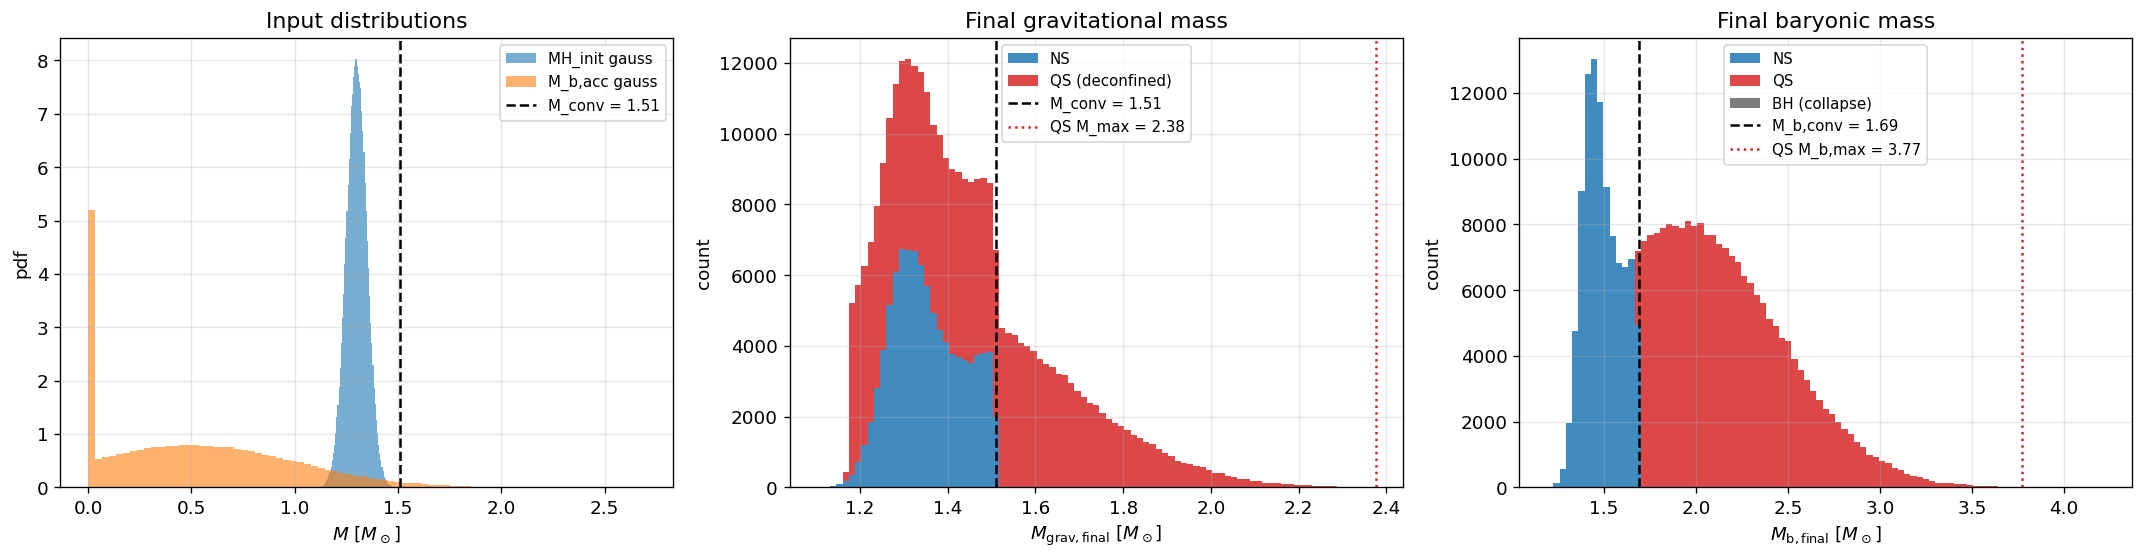

In [10]:
fig, ax = plt.subplots(1, 3, figsize=(18, 4.8))

# (a) inputs
ax[0].hist(MH_init, bins=80, density=True, alpha=0.6, label=f"MH_init {INIT_DIST[0]}")
ax[0].hist(Mb_acc,  bins=80, density=True, alpha=0.6, label=f"M_b,acc {ACC_DIST[0]}")
ax[0].axvline(M_conv, color="k", ls="--", lw=1.5, label=f"M_conv = {M_conv:.2f}")
ax[0].set(xlabel=r"$M\ [M_\odot]$", ylabel="pdf", title="Input distributions")
ax[0].legend(fontsize=9)

# (b) final GRAVITATIONAL mass, stacked by remnant type
bins_g = np.linspace(np.nanmin(M_final), np.nanmax(M_final), 90)
mns, mqs = M_final[kind == "NS"], M_final[kind == "QS"]
ax[1].hist([mns[np.isfinite(mns)], mqs[np.isfinite(mqs)]], bins=bins_g, stacked=True,
           color=["C0", "C3"], alpha=0.85, label=["NS", "QS (deconfined)"])
ax[1].axvline(M_conv, color="k",  ls="--", lw=1.5, label=f"M_conv = {M_conv:.2f}")
ax[1].axvline(Mmax_q, color="C3", ls=":",  lw=1.5, label=f"QS M_max = {Mmax_q:.2f}")
ax[1].set(xlabel=r"$M_{\rm grav,final}\ [M_\odot]$", ylabel="count",
          title="Final gravitational mass")
ax[1].legend(fontsize=9)

# (c) final BARYONIC mass (conserved), stacked by remnant type
bins_b = np.linspace(Mb_final.min(), Mb_final.max(), 90)
ax[2].hist([Mb_final[kind == "NS"], Mb_final[kind == "QS"], Mb_final[kind == "BH"]],
           bins=bins_b, stacked=True, color=["C0", "C3", "0.4"], alpha=0.85,
           label=["NS", "QS", "BH (collapse)"])
ax[2].axvline(Mb_conv,  color="k",  ls="--", lw=1.5, label=f"M_b,conv = {Mb_conv:.2f}")
ax[2].axvline(Mb_max_Q, color="C3", ls=":",  lw=1.5, label=f"QS M_b,max = {Mb_max_Q:.2f}")
ax[2].set(xlabel=r"$M_{\rm b,final}\ [M_\odot]$", ylabel="count",
          title="Final baryonic mass")
ax[2].legend(fontsize=9)

plt.tight_layout(); plt.show()


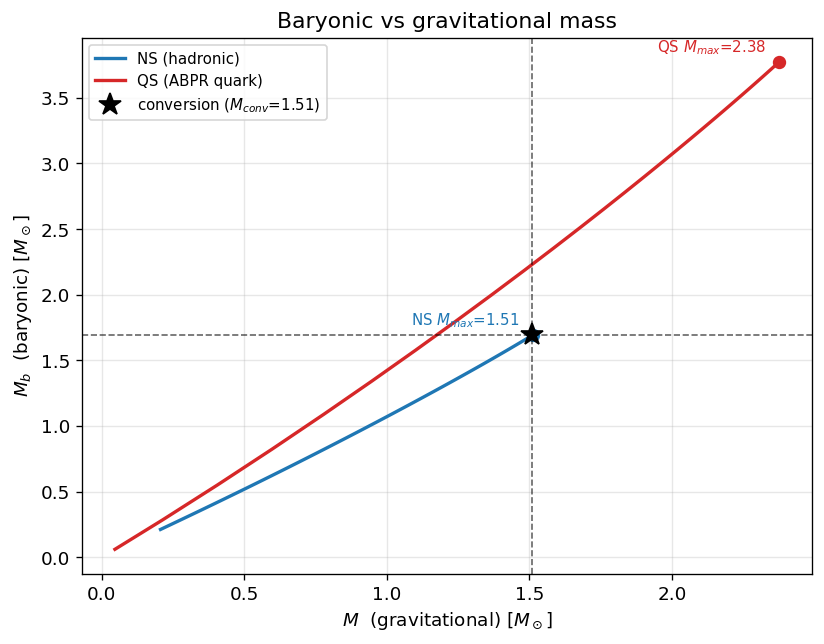

In [11]:
fig, ax = plt.subplots(figsize=(7, 5.5))

# stable branches: x = gravitational mass M, y = baryonic mass M_b
ax.plot(seq_h[:, 4], seq_h[:, 5], "-",  color="C0", label="NS (hadronic)")
ax.plot(seq_q[:, 4], seq_q[:, 5], "-",  color="C3", label="QS (ABPR quark)")

# max-mass points
ax.plot(Mmax_h, seq_h[:, 5].max(), "o", color="C0", ms=7)
ax.plot(Mmax_q, seq_q[:, 5].max(), "o", color="C3", ms=7)
ax.annotate(f"NS $M_{{max}}$={Mmax_h:.2f}", (Mmax_h, seq_h[:, 5].max()),
            textcoords="offset points", xytext=(-8, 6), color="C0", fontsize=9, ha="right")
ax.annotate(f"QS $M_{{max}}$={Mmax_q:.2f}", (Mmax_q, seq_q[:, 5].max()),
            textcoords="offset points", xytext=(-8, 6), color="C3", fontsize=9, ha="right")

# deconfinement threshold on the hadronic branch
ax.plot(M_conv, Mb_conv, "k*", ms=14, label=f"conversion ($M_{{conv}}$={M_conv:.2f})")
ax.axhline(Mb_conv, color="k", ls="--", lw=1, alpha=0.6)
ax.axvline(M_conv,  color="k", ls="--", lw=1, alpha=0.6)

ax.set(xlabel=r"$M$  (gravitational) $[M_\odot]$",
       ylabel=r"$M_b$  (baryonic) $[M_\odot]$",
       title=r"Baryonic vs gravitational mass")
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()
ax.plot(M_conv, Mb_conv, "k*", ms=14, zorder=5,
        label=fr"$M_{{conv}}$ = {M_conv:.2f} $M_\odot$")
ax.legend(fontsize=9)



In [12]:
Mmax_h

1.5132925145973797

In [13]:
 M_conv

1.5102409176901674